In [1]:
import pandas as pd
import numpy as np
import dask.dataframe as dask_data

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot



In [2]:
# Load data

train_data = pd.read_csv('Data/train',
                         parse_dates = ['hour'],
                         date_format = '%y%m%d%H')


In [3]:
train_data = train_data.rename(columns={'hour': 'time'})

In [4]:
# Check data info
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40428967 entries, 0 to 40428966
Data columns (total 24 columns):
 #   Column            Dtype         
---  ------            -----         
 0   id                float64       
 1   click             int64         
 2   time              datetime64[ns]
 3   C1                int64         
 4   banner_pos        int64         
 5   site_id           object        
 6   site_domain       object        
 7   site_category     object        
 8   app_id            object        
 9   app_domain        object        
 10  app_category      object        
 11  device_id         object        
 12  device_ip         object        
 13  device_model      object        
 14  device_type       int64         
 15  device_conn_type  int64         
 16  C14               int64         
 17  C15               int64         
 18  C16               int64         
 19  C17               int64         
 20  C18               int64         
 21  C19   

In [37]:
train_data.describe()

,id,click,time,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
count,4.042897e+07,4.042897e+07,40428967,4.042897e+07,4.042897e+07,4.042897e+07,4.042897e+07,4.042897e+07,4.042897e+07,4.042897e+07,4.042897e+07,4.042897e+07,4.042897e+07,4.042897e+07,4.042897e+07
mean,9.223017e+18,1.698056e-01,2014-10-25 22:33:03.786209024,1.004968e+03,2.880146e-01,1.015305e+00,3.313150e-01,1.884181e+04,3.188831e+02,6.010201e+01,2.112601e+03,1.432499e+00,2.271444e+02,5.321685e+04,8.338229e+01
min,5.211594e+11,0.000000e+00,2014-10-21 00:00:00,1.001000e+03,0.000000e+00,0.000000e+00,0.000000e+00,3.750000e+02,1.200000e+02,2.000000e+01,1.120000e+02,0.000000e+00,3.300000e+01,-1.000000e+00,1.000000e+00
25%,4.611181e+18,0.000000e+00,2014-10-23 04:00:00,1.005000e+03,0.000000e+00,1.000000e+00,0.000000e+00,1.692000e+04,3.200000e+02,5.000000e+01,1.863000e+03,0.000000e+00,3.500000e+01,-1.000000e+00,2.300000e+01
50%,9.223224e+18,0.000000e+00,2014-10-26 02:00:00,1.005000e+03,0.000000e+00,1.000000e+00,0.000000e+00,2.034600e+04,3.200000e+02,5.000000e+01,2.323000e+03,2.000000e+00,3.900000e+01,1.000480e+05,6.100000e+01
75%,1.383561e+19,0.000000e+00,2014-10-28 14:00:00,1.005000e+03,1.000000e+00,1.000000e+00,0.000000e+00,2.189400e+04,3.200000e+02,5.000000e+01,2.526000e+03,3.000000e+00,1.710000e+02,1.000930e+05,1.010000e+02
max,1.844674e+19,1.000000e+00,2014-10-30 23:00:00,1.012000e+03,7.000000e+00,5.000000e+00,5.000000e+00,2.405200e+04,1.024000e+03,1.024000e+03,2.758000e+03,3.000000e+00,1.959000e+03,1.002480e+05,2.550000e+02
std,5.325443e+18,3.754620e-01,NaN,1.094586e+00,5.063820e-01,5.274336e-01,8.547935e-01,4.959457e+03,2.127250e+01,4.729538e+01,6.094124e+02,1.326227e+00,3.510221e+02,4.995682e+04,7.028996e+01


In [45]:
train_data.shape[0]

40428967

Data EDA

Text(0, 0.5, 'Proportion')

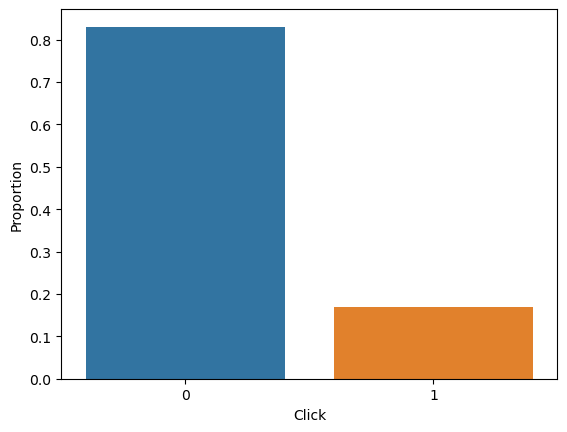

In [55]:
# Plot click vs no click distribution

rows = train_data.shape[0]
click_through_rate = train_data['click'].value_counts()/rows
df_ctr = click_through_rate.reset_index()
df_ctr.columns = ['click', 'proportion']

sns.barplot(df_ctr, x = 'click', y = 'proportion') # Most of the users did not click

plt.xlabel('Click')
plt.ylabel('Proportion')

In [39]:
click_through_rate

click
0    0.830194
1    0.169806
Name: count, dtype: float64

In [ ]:

train_data['hour'] = train_data['time'].dt.strftime('%H')


In [58]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40428967 entries, 0 to 40428966
Data columns (total 25 columns):
 #   Column            Dtype         
---  ------            -----         
 0   id                float64       
 1   click             int64         
 2   time              datetime64[ns]
 3   C1                int64         
 4   banner_pos        int64         
 5   site_id           object        
 6   site_domain       object        
 7   site_category     object        
 8   app_id            object        
 9   app_domain        object        
 10  app_category      object        
 11  device_id         object        
 12  device_ip         object        
 13  device_model      object        
 14  device_type       int64         
 15  device_conn_type  int64         
 16  C14               int64         
 17  C15               int64         
 18  C16               int64         
 19  C17               int64         
 20  C18               int64         
 21  C19   

In [13]:
train_data['hour'].unique()

click_by_hour = train_data.groupby('hour')['click'].sum().reset_index()

In [53]:
click_by_hour

,hour,click
0,00,152429
1,01,182947
2,02,215322
3,03,243705
4,04,305308
5,05,323863
6,06,296346
7,07,332884
8,08,342120
9,09,364461


/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



Text(0, 0.5, 'Number of Click-throughs')

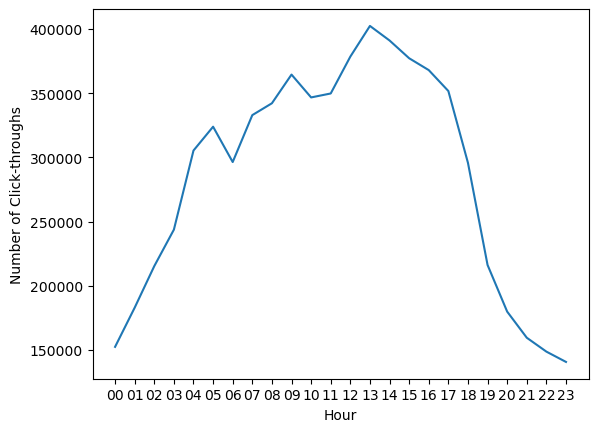

In [ ]:
# Plot click distribution by hour in the day

ax0 = sns.lineplot(x = 'hour', y = 'click', data = click_by_hour)

plt.xlabel('Hour')
plt.ylabel('Number of Click-throughs')

In [49]:
# Write function to add numbers to each segment of stacked bar chart

def add_num_stackedbar(plot):
    for i, bar in enumerate(plot.patches):
        height = bar.get_height()
        width = bar.get_width()
        x = bar.get_x()
        y = bar.get_y()

        if height > 0.01:
            plot.text(
                x + width/2,
                y + height/2,
                f'{height:.1f}', # formatted to 1 decimal place
                ha = 'center',
                va = 'center',
                fontweight = 'bold'
                )

In [15]:
# banner position

train_data['banner_pos'].unique()

array([0, 1, 4, 5, 2, 7, 3])

In [17]:
# Plot click distribution by banner position

banner_temp = train_data.groupby('banner_pos')['click'].value_counts(normalize = True).mul(100).round(2).unstack()
banner_temp

click,0,1
banner_pos,,
0,83.57,16.43
1,81.64,18.36
2,88.08,11.92
3,81.72,18.28
4,81.46,18.54
5,87.85,12.15
7,67.99,32.01


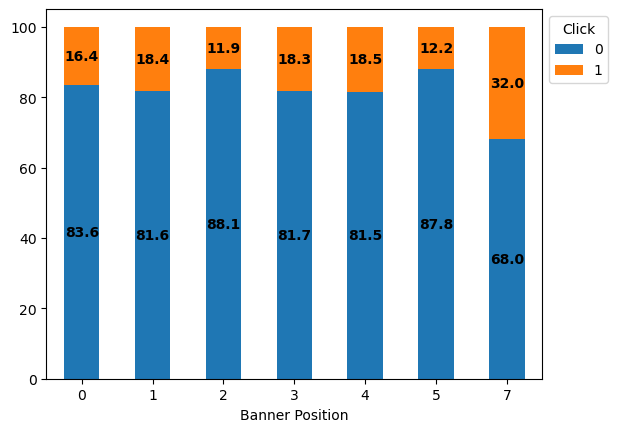

In [52]:
ax = banner_temp.plot(kind = 'bar', stacked = True)

add_num_stackedbar(ax)

plt.xticks(rotation = 0)
plt.xlabel('Banner Position')
plt.legend(loc = 'upper left', bbox_to_anchor = (1, 1), title = 'Click')

In [40]:
# Plot click distribution by device type

device_temp = train_data.groupby('device_type')['click'].value_counts(normalize=True).mul(100).round(2).unstack()
device_temp

click,0,1
device_type,,
0,78.93,21.07
1,83.08,16.92
2,93.55,6.45
4,90.46,9.54
5,90.62,9.38


In [41]:
train_data['device_type'].unique()

array([1, 0, 4, 5, 2])

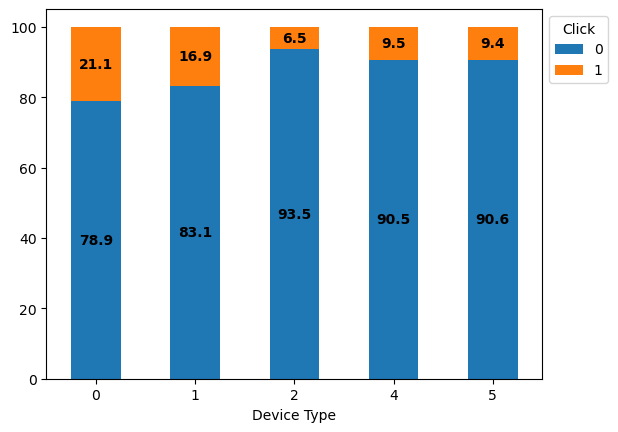

In [51]:
ax1 = device_temp.plot(kind = 'bar', stacked = True)

add_num_stackedbar(ax1)

plt.xticks(rotation = 0)
plt.xlabel('Device Type')
plt.legend(loc = 'upper left', bbox_to_anchor = (1, 1), title = 'Click')

In [5]:
# Check the app categories with largest number of click-throughs
# Some app categories had 0 click-through

app_temp = train_data.groupby('app_category')['click'].sum().reset_index().sort_values(by = 'click', ascending = False)
app_temp

,app_category,click
0,07d7df22,5210822
4,0f2161f8,1033720
34,f95efa07,282664
29,cef3e649,161450
21,8ded1f7a,132021
30,d1327cf5,15197
31,dc97ec06,8552
1,09481d60,8518
17,75d80bbe,3849
11,4ce2e9fc,2570


In [6]:
top10_apps = app_temp[:10]['app_category'].to_list()

In [7]:
top10_apps

['07d7df22',
 '0f2161f8',
 'f95efa07',
 'cef3e649',
 '8ded1f7a',
 'd1327cf5',
 'dc97ec06',
 '09481d60',
 '75d80bbe',
 '4ce2e9fc']

In [ ]:
app_temp = train_data[train_data['app_category'].isin(top10_apps)].groupby('app_category')['click'].value_counts().unstack()
app_temp['total'] = app_temp.sum(axis=1)
app_temp_sorted = app_temp.sort_values(by = 'total', ascending = False)
app_temp_sorted = app_temp_sorted.drop('total', axis = 1)

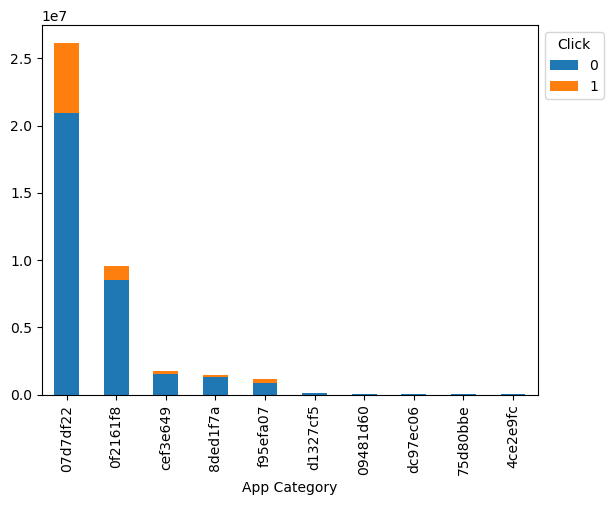

In [10]:
ax2 = app_temp_sorted.plot(kind = 'bar', stacked = True)

# add_num_stackedbar(ax2)

plt.xlabel('App Category')
plt.legend(loc = 'upper left', bbox_to_anchor = (1, 1), title = 'Click')

In [11]:
site_temp = train_data.groupby('site_category')['click'].sum().reset_index().sort_values(by = 'click', ascending = False)
site_temp

,site_category,click
24,f028772b,2272940
6,50e219e0,2126350
2,28905ebd,1534600
4,3e814130,863245
12,75fa27f6,17915
3,335d28a8,12779
22,dedf689d,12593
25,f66779e6,10019
19,c0dd3be3,4714
9,70fb0e29,3298


In [12]:
top10_sites = site_temp[:10]['site_category'].to_list()

In [13]:
site_temp = train_data[train_data['site_category'].isin(top10_sites)].groupby('site_category')['click'].value_counts().unstack()
site_temp['total'] = site_temp.sum(axis=1)
site_temp_sorted = site_temp.sort_values(by = 'total', ascending = False)
site_temp_sorted = site_temp_sorted.drop('total', axis = 1)

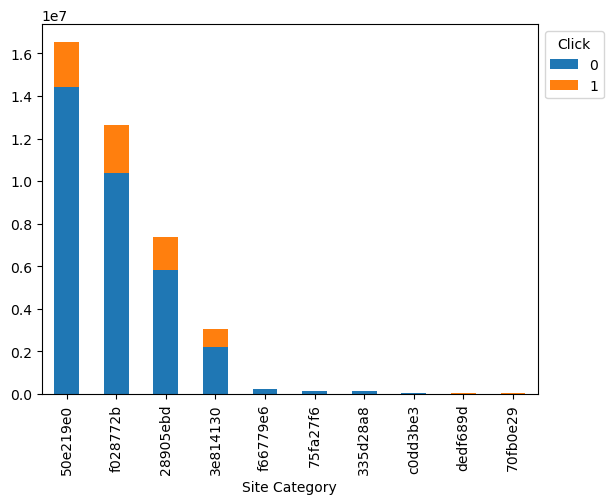

In [14]:
ax3 = site_temp_sorted.plot(kind = 'bar', stacked = True)

plt.xlabel('Site Category')
plt.legend(loc = 'upper left', bbox_to_anchor = (1, 1), title = 'Click')